# Helmet Detection API — Test Client

This notebook:
1. Hits the `/predict` endpoint with a local image using `requests`.
2. Parses the returned bounding boxes.
3. Displays the image with boxes, class names, and confidence scores overlaid.

> **Prerequisites**: Start the API with `uvicorn main:app --reload` before running.

In [ ]:
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import io
import json

In [30]:
# ── Configuration ──────────────────────────────────────────────────────────────
API_BASE_URL = "http://127.0.0.1:8000"
PREDICT_ENDPOINT = f"{API_BASE_URL}/predict"

# Change this to the path of any image you want to test
IMAGE_PATH = "safety helmet.jpg"  # <-- update this path
IMAGE_PATH = "helmet2.jpg"  # <-- update this path
IMAGE_PATH = "helmet3.jpg"  # <-- update this path
IMAGE_PATH = "helmet4.png"  # <-- update this path
IMAGE_PATH = "helmet5.jpeg"  # <-- update this path

In [ ]:
# ── Health Check ────────────────────────────────────────────────────────────png───
health = requests.get(f"{API_BASE_URL}/health", timeout=10)
print("Status code:", health.status_code)
print("Response:", json.dumps(health.json(), indent=2))

In [138]:
# ── Send Image to /predict ─────────────────────────────────────────────────────
with open(IMAGE_PATH, "rb") as f:
    image_bytes = f.read()

response = requests.post(
    PREDICT_ENDPOINT,
    files={"file": (IMAGE_PATH, image_bytes, "image/jpeg")},
    timeout=30,
)

print("Status code:", response.status_code)
result = response.json()
print(json.dumps(result, indent=2))

Status code: 429
{
  "error": "rate_limit_exceeded",
  "detail": "Rate limit exceeded: 60 per 1 minute. Please slow down."
}


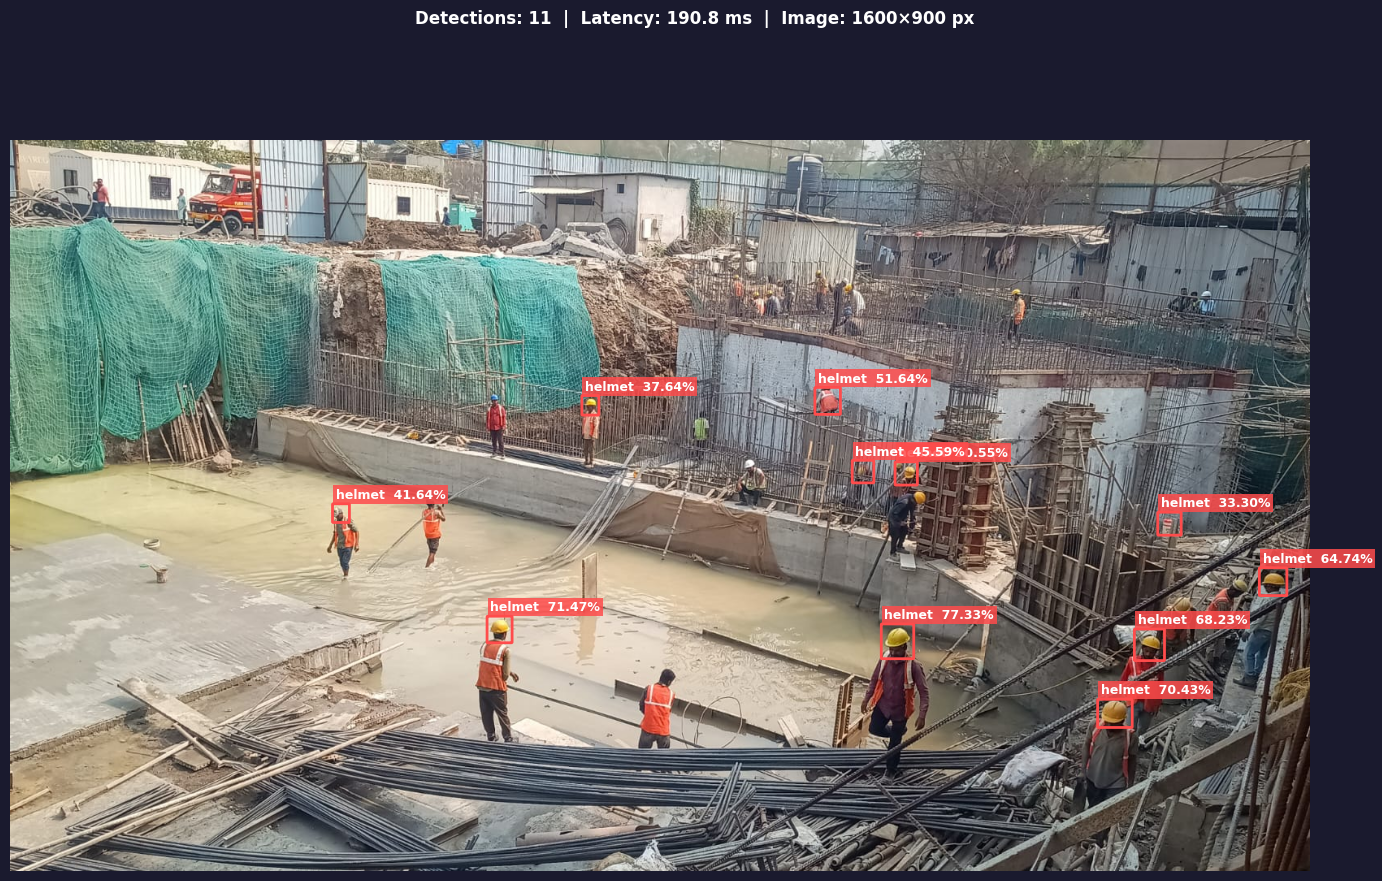

In [33]:
# ── Visualise Detections ───────────────────────────────────────────────────────

# Colour palette — one colour per class_id (cycles if more than 10 classes)
PALETTE = [
    "#FF4C4C", "#4CAF50", "#2196F3", "#FF9800",
    "#9C27B0", "#00BCD4", "#FFEB3B", "#E91E63",
    "#8BC34A", "#FF5722",
]

detections = result.get("detections", [])
num_detections = result.get("num_detections", 0)
latency_ms = result.get("latency_ms", "N/A")

# Load image with PIL (RGB)
img = Image.open(IMAGE_PATH).convert("RGB")
img_width, img_height = img.size

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(np.array(img))
ax.set_axis_off()
fig.patch.set_facecolor("#1a1a2e")

for det in detections:
    x1, y1, x2, y2 = det["bbox"]
    conf = det["confidence"]
    cls_id = det["class_id"]
    cls_name = det["class_name"]
    color = PALETTE[cls_id % len(PALETTE)]

    w = x2 - x1
    h = y2 - y1

    # Bounding box rectangle
    rect = patches.FancyBboxPatch(
        (x1, y1), w, h,
        boxstyle="round,pad=1",
        linewidth=2,
        edgecolor=color,
        facecolor="none",
        zorder=2,
    )
    ax.add_patch(rect)

    # Label background
    label = f"{cls_name}  {conf:.2%}"
    ax.text(
        x1 + 3, y1 - 8,
        label,
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor=color, alpha=0.85, pad=2, linewidth=0),
        zorder=3,
    )

title = (
    f"Detections: {num_detections}  |  "
    f"Latency: {latency_ms} ms  |  "
    f"Image: {img_width}×{img_height} px"
)
fig.suptitle(title, color="white", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()